    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
5  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0      0.8   
6  62.0  0.0  4.0     140.0  268.0  0.0      2.0    160.0    0.0      3.6   
7  57.0  0.0  4.0     120.0  354.0  0.0      0.0    163.0    1.0      0.6   
8  63.0  1.0  4.0     130.0  254.0  0.0      2.0    147.0    0.0      1.4   
9  53.0  1.0  4.0     140.0  203.0  1.0      2.0    155.0    1.0      3.1   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4 

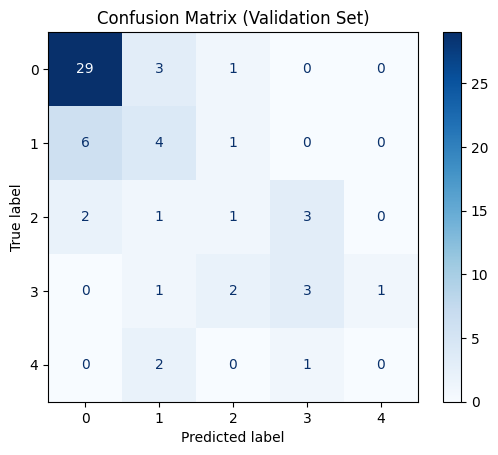


🔍 Performance Report:
Validation Set → Accuracy=0.607, Precision=0.562, Recall=0.607, F1=0.582
K-Fold CV → Accuracy=0.591
Stratified K-Fold CV → Accuracy=0.591
LOO → Accuracy=0.594


In [1]:
# ----------------------------
# 1. Import Libraries
# ----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# ----------------------------
# 2. Load Dataset
# ----------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
# The dataset has no header, so we need to provide column names
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv(url, names=column_names, na_values='?') # '?' represents missing values
print(df.head(10))

X = df.drop("target", axis=1)
y = df["target"]

# ----------------------------
# Handle missing values (Imputation)
# The error message indicates that the model cannot handle NaNs.
# We will impute the missing values using the mean of each column.
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)


# ----------------------------
# 3. Scale Features
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 4. Logistic Regression Model
# ----------------------------
model = LogisticRegression(max_iter=1000, solver="lbfgs")

# ----------------------------
# 5a. Validation Set Approach
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)

acc_val = accuracy_score(y_val, y_pred_val)
prec_val = precision_score(y_val, y_pred_val, average='weighted', zero_division=0)
rec_val = recall_score(y_val, y_pred_val, average='weighted', zero_division=0)
f1_val = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)

print("\n📌 Validation Set Results:")
print(f"Accuracy: {acc_val:.3f}, Precision: {prec_val:.3f}, Recall: {rec_val:.3f}, F1: {f1_val:.3f}")

# ----------------------------
# 5b. K-Fold Cross Validation
# ----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf = cross_val_score(model, X_scaled, y, cv=kf, scoring="accuracy")
print("\n📌 K-Fold CV Accuracy:", scores_kf.mean())

# ----------------------------
# 5c. Stratified K-Fold Cross Validation
# ----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")
print("📌 Stratified K-Fold CV Accuracy:", scores_skf.mean())

# ----------------------------
# 5d. Leave-One-Out Cross Validation (LOO)
# ----------------------------
loo = LeaveOneOut()
scores_loo = cross_val_score(model, X_scaled, y, cv=loo, scoring="accuracy")
print("📌 LOO Accuracy:", scores_loo.mean())

# ----------------------------
# 6. Confusion Matrix (Validation Set)
# ----------------------------
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# ----------------------------
# 7. Final Report
# ----------------------------
print("\n🔍 Performance Report:")
print(f"Validation Set → Accuracy={acc_val:.3f}, Precision={prec_val:.3f}, Recall={rec_val:.3f}, F1={f1_val:.3f}")
print(f"K-Fold CV → Accuracy={scores_kf.mean():.3f}")
print(f"Stratified K-Fold CV → Accuracy={scores_skf.mean():.3f}")
print(f"LOO → Accuracy={scores_loo.mean():.3f}")